
## MACHINE LEARNING IN FINANCE
MODULE 7 | LESSON 2


---

# **HOUSE PREDICTION AND HYPERPARAMETER TUNING**


|  |  |
|:---|:---|
|**Reading Time** |  35 minutes |
|**Prior Knowledge** | Grid Search, Random Search  |
|**Keywords** |Grid search  |


---

*In the last lesson, we introduced hyperparameter tuning in machine learning and the merits and demerits of the various algorithms used. In this lesson, we will apply the skills learned to a house prediction exercise.*

## **1. Introduction**

In this lesson we will use the housing data from the [Geo Data and Lab](https://geodacenter.github.io/data-and-lab/KingCounty-HouseSales2015/) website to predict the housing prices using Random Forest Regression and later on fine-tune its hyperparameters so as to improve the model performance.

We begin by first loading the relevant packages below.

In [1]:
# data manipulation and plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# from Scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

We then load the downloaded file to our working space and read it.

In [2]:
df = pd.read_csv("kc_house_data.csv")

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Since the data is already processed, we will lightly touch on the exploratory data analysis phase and concentrate mostly on the modeling phase.

Below we can see the size of the data and examine missing values.

## **2. Exploratory Data Analysis**

In [4]:
print(f"The dataset contains {df.shape[0]} samples and " f"{df.shape[1]} features")

The dataset contains 21613 samples and 21 features


In [5]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

We then drop the id and date column from our data as they will not be useful for our prediction exercise. We also separate the target variable from the predictor variables.

In [6]:
X = df.drop(["id", "price", "date"], axis=1)
y = df["price"]

The next step is to pick out categorical variables from numerical variables using column selector from `sklearn`'s compose.

In [7]:
from sklearn.compose import make_column_selector as selector

categorical_columns_selector = selector(dtype_include=object)
categorical_columns = categorical_columns_selector(X)
categorical_columns

[]

In [8]:
# now let's identify the numerical variables

num_vars = [var for var in X.columns if var not in categorical_columns]

# number of numerical variables
print(len(num_vars))
print(num_vars)

18
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


We note that some categorical variables are numerical and we can put them into their correct list.

In [9]:
#  let's make a list of discrete variables
categorical_vars = [var for var in num_vars if len(X[var].unique()) < 20]


print("Number of categorical variables: ", len(categorical_vars))
print(categorical_vars)

Number of categorical variables:  6
['bedrooms', 'floors', 'waterfront', 'view', 'condition', 'grade']


In [10]:
# let's visualize the categorical variables

X[categorical_vars].head()

,bedrooms,floors,waterfront,view,condition,grade
0,3,1.0,0,0,3,7
1,3,2.0,0,0,3,7
2,2,1.0,0,0,3,6
3,4,1.0,0,0,5,7
4,3,1.0,0,0,3,8


Therefore, the remaining numerical variables will now be classified as continuous variables.

In [11]:
# make list of continuous variables
cont_vars = [var for var in num_vars if var not in categorical_vars]

print("Number of continuous variables: ", len(cont_vars))
print(cont_vars)

Number of continuous variables:  12
['bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [12]:
# let's visualize the continuous variables

X[cont_vars].head()

,bathrooms,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1.00,1180,5650,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,2.25,2570,7242,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,1.00,770,10000,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3.00,1960,5000,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2.00,1680,8080,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


We now visualize the variables' distribution using histograms as shown below.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

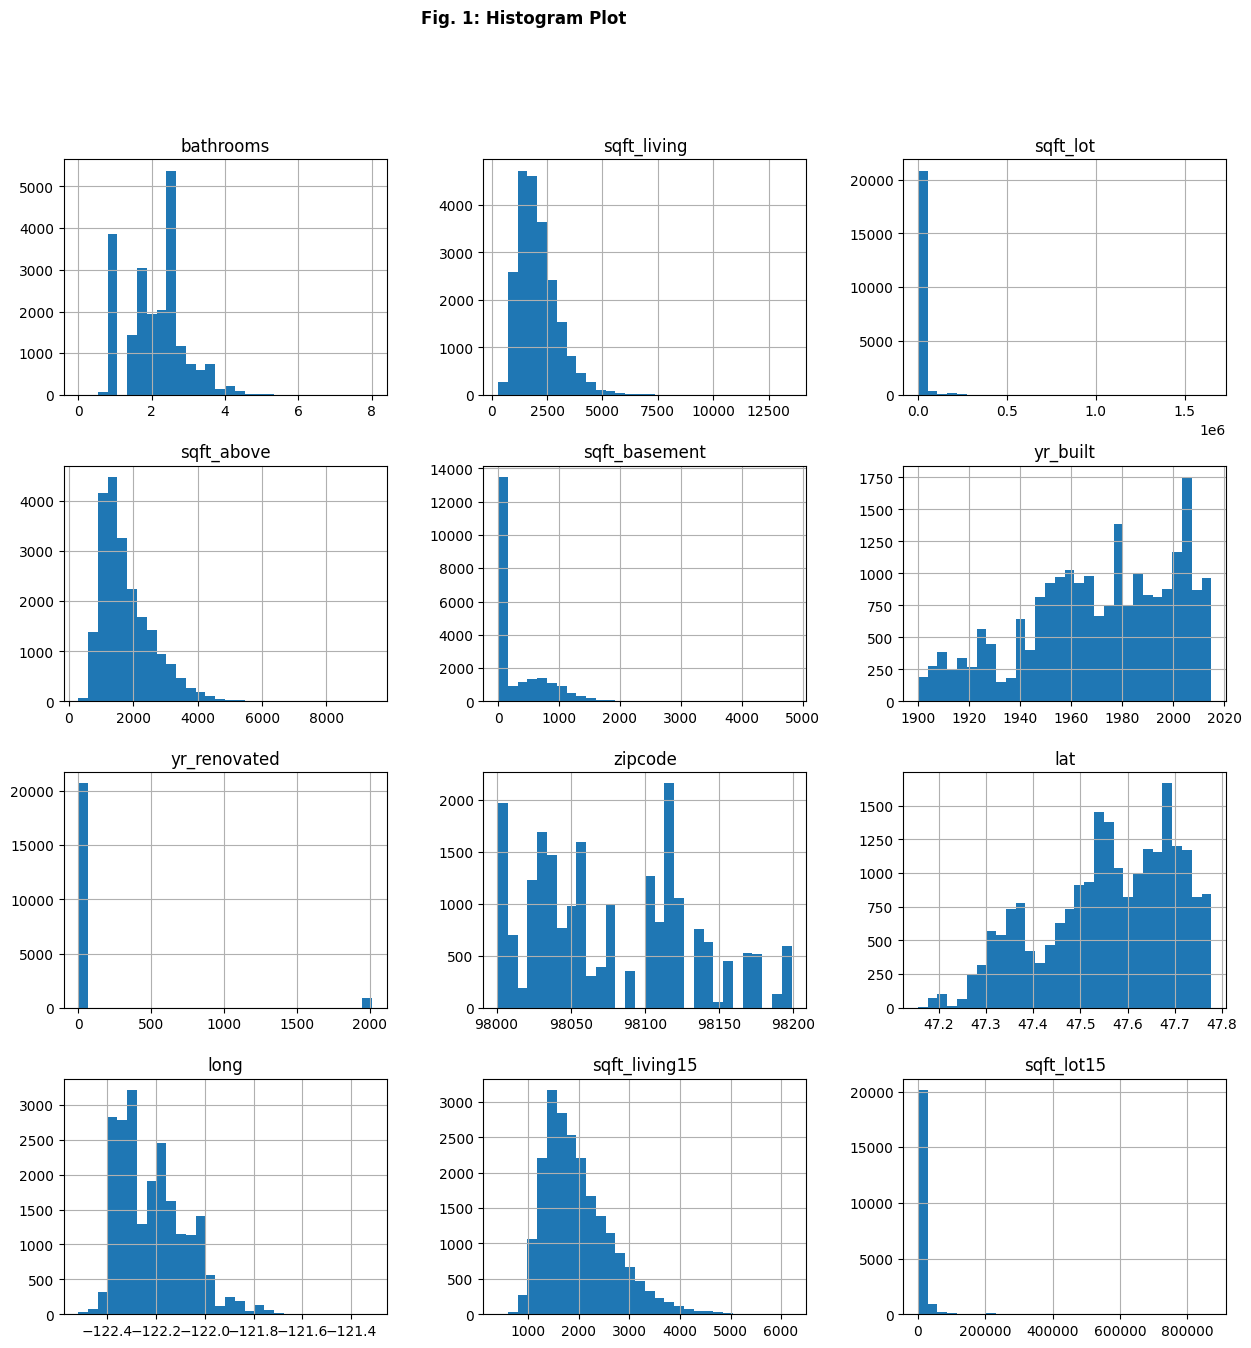

In [13]:
# lets plot histograms for all continuous variables

X[cont_vars].hist(bins=30, figsize=(15, 15))
plt.suptitle("Fig. 1: Histogram Plot", fontweight="bold", horizontalalignment="right")
plt.show()

We can now standardize the continuous variables and encode the discrete variables to eliminate possible bias towards larger values.

## **3. Modeling Pipeline**

In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()

In [15]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    [
        ("one-hot-encoder", categorical_preprocessor, categorical_vars),
        ("standard_scaler", numerical_preprocessor, cont_vars),
    ]
)

We now create a pipeline of our regression model as shown below.

In [16]:
model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(random_state=42)),
    ]
)

In [17]:
from sklearn import set_config

set_config(display="diagram")
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('one-hot-encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['bedrooms', 'floors',
                                                   'waterfront', 'view',
                                                   'condition', 'grade']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['bathrooms', 'sqft_living',
                                                   'sqft_lot', 'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'zipcode',
                                                   'lat', 'long',
                                                   'sqft_living15',
                                                   'sqft_lot15'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

The data is now split into training data and testing data.

In [18]:
# Let's separate into train and test set
# Remember to set the seed (random_state for this `sklearn` function)

X_train, X_test, y_train, y_test = train_test_split(
    X,  # predictive variables
    y,  # target
    test_size=0.3,  # portion of dataset to allocate to test set
    random_state=0,  # we are setting the seed here
)

X_train.shape, X_test.shape

((15129, 18), (6484, 18))

We can note below that the target variable is skewed to the left and our model will have a tendency to predict values to the most common value. Therefore, we transform it to make it more normal.

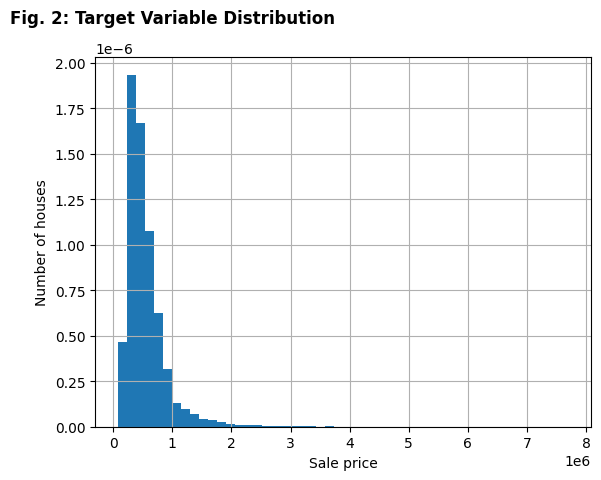

In [19]:
# histogram to evaluate target distribution

df["price"].hist(bins=50, density=True)
plt.ylabel("Number of houses")
plt.xlabel("Sale price")
plt.suptitle(
    "Fig. 2: Target Variable Distribution",
    fontweight="bold",
    horizontalalignment="right",
)
plt.show()

After log transforming the target variable, it now looks more normally distributed and will therefore use the log transform variable as our target.

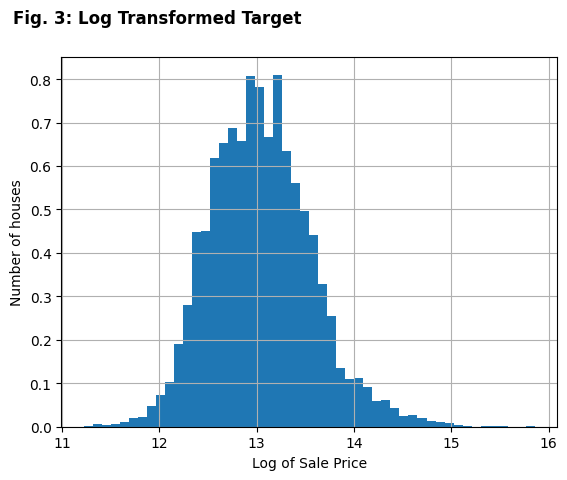

In [20]:
# let's transform the target using the logarithm

np.log(df["price"]).hist(bins=50, density=True)
plt.ylabel("Number of houses")
plt.xlabel("Log of Sale Price")
plt.suptitle(
    "Fig. 3: Log Transformed Target", fontweight="bold", horizontalalignment="right"
)
plt.show()

In [21]:
y_train = np.log(y_train)
y_test = np.log(y_test)

In [22]:
X_train.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1468,4,1.50,1390,7200,1.0,0,0,3,7,1140,250,1965,0,98133,47.7224,-122.332,1630,7702
15590,3,1.50,1450,7316,1.0,0,0,3,7,1450,0,1961,0,98133,47.7725,-122.349,1440,7316
18552,5,2.75,2860,5379,2.0,0,0,3,9,2860,0,2005,0,98052,47.7082,-122.104,2980,6018
10535,2,1.00,1050,4125,1.0,0,0,4,7,1050,0,1909,0,98144,47.5736,-122.307,1650,4125
1069,2,1.00,1240,57000,1.0,0,0,3,7,1240,0,1962,0,98075,47.5970,-122.059,3050,25545


We now train the model using the pipeline we formulated above.

In [23]:
_ = model.fit(X_train, y_train)

In [24]:
X_test.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
17384,2,1.50,1430,1650,3.0,0,0,3,7,1430,0,1999,0,98125,47.7222,-122.290,1430,1650
722,4,3.25,4670,51836,2.0,0,0,4,12,4670,0,1988,0,98005,47.6350,-122.164,4230,41075
2680,2,0.75,1440,3700,1.0,0,0,3,7,1200,240,1914,0,98107,47.6707,-122.364,1440,4300
18754,2,1.00,1130,2640,1.0,0,0,4,8,1130,0,1927,0,98109,47.6438,-122.357,1680,3200
14554,4,2.50,3180,9603,2.0,0,2,3,9,3180,0,2002,0,98155,47.7717,-122.277,2440,15261


We then use the model to make predictions about unseen test data and evaluate its performance.

In [25]:
target_predicted = model.predict(X_test)

print(
    f"Mean squared error on the testing set: "
    f"{mean_squared_error(y_test, target_predicted):.3f}"
)

Mean squared error on the testing set: 0.031


## **4. Regression Metrics**

There are various metrics we can use to evaluate the performance of a regression model.

In [26]:
model.score(X_test, y_test)

0.8880587100455746

The model performed really well, and we will now want to see if we can improve this performance using hyperparameter tuning.

In [27]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor.fit(X_train, y_train)
print(
    f"R2 score for a regressor predicting the mean:"
    f"{dummy_regressor.score(X_test, y_test):.3f}"
)

R2 score for a regressor predicting the mean:-0.000


In [28]:
from sklearn.metrics import mean_absolute_error

print(f"Mean absolute error: " f"{mean_absolute_error(y_test, target_predicted):.3f} $")

Mean absolute error: 0.124 $


## **5. Hyperparameter Tuning**

### **5.1 Random Search**

We will need to define the hyperparameter grid to be able to use random search.

In [29]:
from pprint import pprint

# Look at parameters used by our current forest
print("Parameters currently in use:\n")
pprint(model.get_params())

Parameters currently in use:

{'memory': None,
 'preprocessor': ColumnTransformer(transformers=[('one-hot-encoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['bedrooms', 'floors', 'waterfront', 'view',
                                  'condition', 'grade']),
                                ('standard_scaler', StandardScaler(),
                                 ['bathrooms', 'sqft_living', 'sqft_lot',
                                  'sqft_above', 'sqft_basement', 'yr_built',
                                  'yr_renovated', 'zipcode', 'lat', 'long',
                                  'sqft_living15', 'sqft_lot15'])]),
 'preprocessor__force_int_remainder_cols': True,
 'preprocessor__n_jobs': None,
 'preprocessor__one-hot-encoder': OneHotEncoder(handle_unknown='ignore'),
 'preprocessor__one-hot-encoder__categories': 'auto',
 'preprocessor__one-hot-encoder__drop': None,
 'preprocessor__one-hot-encoder__dtype': <class 'numpy.

Random search has the advantage of being fast as it does not use all the values in the hyperparameter space but rather randomly selects variables.

In [30]:
from sklearn.model_selection import RandomizedSearchCV

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start=10, stop=90, num=10)]
# Number of features to consider at every split
max_features = ["auto", "sqrt"]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 50, num=21)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {
    "regressor__n_estimators": n_estimators,
    "regressor__max_features": max_features,
    "regressor__max_depth": max_depth,
    "regressor__min_samples_split": min_samples_split,
    "regressor__min_samples_leaf": min_samples_leaf,
    "regressor__bootstrap": bootstrap,
}
pprint(random_grid)

{'regressor__bootstrap': [True, False],
 'regressor__max_depth': [10,
                          12,
                          14,
                          16,
                          18,
                          20,
                          22,
                          24,
                          26,
                          28,
                          30,
                          32,
                          34,
                          36,
                          38,
                          40,
                          42,
                          44,
                          46,
                          48,
                          50,
                          None],
 'regressor__max_features': ['auto', 'sqrt'],
 'regressor__min_samples_leaf': [1, 2, 4],
 'regressor__min_samples_split': [2, 5, 10],
 'regressor__n_estimators': [10, 18, 27, 36, 45, 54, 63, 72, 81, 90]}


We now create a model with all the parameters specified above.

In [31]:
model_random_search = RandomizedSearchCV(
    model,
    param_distributions=random_grid,
    n_iter=10,
    cv=5,
    verbose=1,
)
model_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/site-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('one-hot-encoder',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['bedrooms',
                                                                                'floors',
                                                                                'waterfront',
                                                                                'view',
                                                                                'condition',
                                                                                'grade']),
                                                                              ('standard_scaler',
                                                                               StandardScaler(),
                                                                               ['bathrooms',
                                                                                'sqft_living',
                                                                                'sqft_lot',
                                                                                'sqft_above',
                                                                                'sqft_basement',
                                                                                'yr_built',
                                                                                'yr_renovated',
                                                                                'z...
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'regressor__bootstrap': [True, False],
                                        'regressor__max_depth': [10, 12, 14, 16,
                                                                 18, 20, 22, 24,
                                                                 26, 28, 30, 32,
                                                                 34, 36, 38, 40,
                                                                 42, 44, 46, 48,
                                                                 50, None],
                                        'regressor__max_features': ['auto',
                                                                    'sqrt'],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [10, 18, 27,
                                                                    36, 45, 54,
                                                                    63, 72, 81,
                                                                    90]},
                   verbose=1)

We can now visualize the best hyperparameters that we will fit back to our model.

In [32]:
model_random_search.best_params_

{'regressor__n_estimators': 63,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_features': 'sqrt',
 'regressor__max_depth': None,
 'regressor__bootstrap': False}

By using this hyperparameter values, we now evaluate our algorithm's performance.

In [33]:
def evaluate(model, test_features, test_labels):
    predictions = model.predict(test_features)
    errors = abs(predictions - test_labels)
    mape = 100 * np.mean(errors / test_labels)
    accuracy = 100 - mape
    print("Model Performance")
    print("Average Error: {:0.4f} dollars.".format(np.mean(errors)))
    print("Accuracy = {:0.2f}%.".format(accuracy))

    return accuracy


base_model = RandomForestRegressor(n_estimators=10, random_state=42)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)

Model Performance
Average Error: 0.1299 dollars.
Accuracy = 99.00%.


In [34]:
best_random = model_random_search.best_estimator_
random_accuracy = evaluate(best_random, X_test, y_test)

Model Performance
Average Error: 0.1297 dollars.
Accuracy = 99.00%.


Comparing the performance of our model without and with hyperparameter tuning show us a marginal increase in accuracy.

In [35]:
print(
    "Improvement of {:0.2f}%.".format(
        100 * (random_accuracy - base_accuracy) / base_accuracy
    )
)

Improvement of 0.00%.


### **5.2 Grid Search**

We now provide a framework for performing grid search on our model hyperparameters. Note that we restricted the hyperparameters to a smaller space since the grid search algorithm is very heavy. We therefore do not expect a better performance. Students are allowed to experiment with bigger spaces and see how the model performs.

In [36]:
from sklearn.model_selection import GridSearchCV

# Create the parameter grid based on the results of random search
param_grid = {
    "regressor__bootstrap": [True],
    "regressor__max_depth": [int(x) for x in np.linspace(10, 20, num=6)],
    "regressor__max_features": [2, 3],
    "regressor__min_samples_leaf": [3, 4, 5],
    "regressor__min_samples_split": [8, 10, 12],
    "regressor__n_estimators": [
        int(x) for x in np.linspace(start=70, stop=100, num=11)
    ],
}
# Create a based model
rf = RandomForestRegressor()
# Instantiate the grid search model
grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2
)

In [37]:
# Fit the grid search to the data
grid_search.fit(X_train, y_train)
grid_search.best_params_

Fitting 3 folds for each of 1188 candidates, totalling 3564 fits
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__max_features=2, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=70; total time=   0.5s
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__max_features=2, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=70; total time=   0.6s
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__max_features=2, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=70; total time=   0.6s
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__max_features=2, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=73; total time=   0.6s
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__max_features=2, regressor__min_samples_leaf=3, regressor__min_samples_s

{'regressor__bootstrap': True,
 'regressor__max_depth': 20,
 'regressor__max_features': 3,
 'regressor__min_samples_leaf': 3,
 'regressor__min_samples_split': 10,
 'regressor__n_estimators': 97}

In [38]:
best_grid = grid_search.best_estimator_
grid_accuracy = evaluate(best_grid, X_test, y_test)

Model Performance
Average Error: 0.1731 dollars.
Accuracy = 98.67%.


We also compare the performance of the grid search algorithm with that of the original random forest algorithm.

In [39]:
print(
    "Improvement of {:0.2f}%.".format(
        100 * (grid_accuracy - base_accuracy) / base_accuracy
    )
)

Improvement of -0.33%.


## **Conclusion**

In this lesson, we have seen how to apply hyperparameter tuning to a regression problem. In the next lesson, we will study objective functions and other techniques used to evaluate machine learning models.


**References**

1. Breiman, Leo. "Random Forests." *Machine Learning*, vol. 45, no. 1, 2001, pp 5-32.
2. GeoDa Data and Lab. "2014-15 Home Sales in King County, WA." https://geodacenter.github.io/data-and-lab/KingCounty-HouseSales2015/
3. Ramadhan, Muhammad Murtadha, et al. "Parameter Tuning in Random Forest based on Grid Search Method for Gender Classification based on Voice Frequency." *DEStech Transactions on Computer Science and Engineering*, vol. 10, 2017.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
